LAB EXERCISE 3: Student Survey - Simple Linear Regression
Using Scikit-Learn, OLS, and Parameter Saving

Aim: To collect real-world student survey data, preprocess it, perform
Simple Linear Regression using Scikit-learn and manual OLS, compare both
approaches, and save the learned model parameters.

# PART A: DATA COLLECTION AND PREPROCESSING

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("PART A: DATA COLLECTION AND PREPROCESSING")
print("=" * 70)

PART A: DATA COLLECTION AND PREPROCESSING


In [17]:
# STEP 1: Load the dataset using Pandas
print("\n--- STEP 1: Load the dataset ---")
df = pd.read_excel("Department Awareness Survey (Responses).xlsx")
print("Dataset loaded successfully!")


--- STEP 1: Load the dataset ---
Dataset loaded successfully!


In [18]:
# STEP 2: Display the first 5 rows
print("\n--- STEP 2: First 5 rows ---")
print(df.head())


--- STEP 2: First 5 rows ---
                Timestamp Registration Number   \
0 2026-06-22 08:49:31.362              2547123   
1 2026-06-22 08:49:50.520              2547122   
2 2026-06-22 08:50:44.521              2547101   
3 2026-06-22 08:51:00.666              2547156   
4 2026-06-22 08:51:42.357              2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in\n  \
0                     Software Engineer   
1                         Data Engineer   
2                     Software Engineer   
3                        Data Scientist   
4                     Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0      

In [19]:
# STEP 3: Check dataset dimensions
print("\n--- STEP 3: Dataset dimensions ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Shape: {df.shape}")


--- STEP 3: Dataset dimensions ---
Number of rows: 54
Number of columns: 15
Shape: (54, 15)


In [20]:
# STEP 4: Identify missing values
print("\n--- STEP 4: Missing values ---")
print(df.isnull().sum())



--- STEP 4: Missing values ---
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are

In [21]:
# STEP 5: Remove or handle null values
print("\n--- STEP 5: Handle null values ---")
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("\n", "")

cia_col = "your_CIA_%_of_last_semester"
gpa_col = "your_GPA_of_last_semester"
attendance_col = "Your_maximum_attendance_%_till_last_semester"

print(f"Extracting columns: {cia_col}, {gpa_col}, {attendance_col}")


--- STEP 5: Handle null values ---
Extracting columns: your_CIA_%_of_last_semester, your_GPA_of_last_semester, Your_maximum_attendance_%_till_last_semester


In [22]:
# STEP 6: Convert required columns into numerical datatype
print("\n--- STEP 6: Convert to numerical datatype ---")

def clean_numeric_column(series, col_name):
    s = series.astype(str).str.strip()
    invalid_values = ["Option 1", "na", "NA", "N/A", "n/a", "-", "", " "]
    s = s.replace(invalid_values, np.nan)
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("LPA", "", regex=False)
    s = s.str.replace("lpa", "", regex=False)
    s = s.str.replace("to", "-", regex=False)
    s = s.str.replace("+", "", regex=False)
    numeric = pd.to_numeric(s, errors="coerce")
    print(f"  {col_name}: Converted to numeric. Missing values: {numeric.isna().sum()}")
    return numeric

cia_clean = clean_numeric_column(df[cia_col], "CIA %")
gpa_clean = clean_numeric_column(df[gpa_col], "GPA")
attendance_clean = clean_numeric_column(df[attendance_col], "Attendance %")

df_clean = pd.DataFrame({
    "CIA_Percentage": cia_clean,
    "GPA": gpa_clean,
    "Attendance_Percentage": attendance_clean
})
print("\nCleaned dataframe (first 10 rows):")
print(df_clean.head(10))

def fix_percentage(val):
    if pd.isna(val):
        return val
    if val < 1:
        return val * 100
    if val > 100:
        return np.nan
    return val

def fix_gpa(val):
    if pd.isna(val):
        return val
    if val > 10:
        return np.nan
    return val

df_clean["CIA_Percentage"] = df_clean["CIA_Percentage"].apply(fix_percentage)
df_clean["Attendance_Percentage"] = df_clean["Attendance_Percentage"].apply(fix_percentage)
df_clean["GPA"] = df_clean["GPA"].apply(fix_gpa)



--- STEP 6: Convert to numerical datatype ---
  CIA %: Converted to numeric. Missing values: 1
  GPA: Converted to numeric. Missing values: 1
  Attendance %: Converted to numeric. Missing values: 6

Cleaned dataframe (first 10 rows):
   CIA_Percentage    GPA  Attendance_Percentage
0           78.00   3.24                    NaN
1           64.78   3.20                    NaN
2           80.00   3.60                    NaN
3           70.00   3.20                  92.00
4           68.00   3.40                  85.00
5            0.70   3.50                   0.87
6            0.88   3.70                    NaN
7            3.45  10.00                  90.00
8           70.00   3.40                  89.00
9           83.00   3.89                  98.00


In [23]:
# STEP 7: Remove duplicate records if present
print("\n--- STEP 7: Remove duplicates ---")
print(f"Before removing duplicates: {len(df_clean)} rows")
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {len(df_clean)} rows")

# Remove only genuine outliers using IQR method
print("Removing outliers using IQR method...")
for col in ["CIA_Percentage", "GPA", "Attendance_Percentage"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    print(f"  {col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, range=[{lower:.2f}, {upper:.2f}], removed {before - len(df_clean)} rows")

print(f"After removing outliers: {len(df_clean)} rows")

df_clean = df_clean.dropna()
print(f"After dropping rows with missing values: {len(df_clean)} rows")


--- STEP 7: Remove duplicates ---
Before removing duplicates: 54 rows
After removing duplicates: 53 rows
Removing outliers using IQR method...
  CIA_Percentage: Q1=70.00, Q3=79.50, IQR=9.50, range=[55.75, 93.74], removed 3 rows
  GPA: Q1=3.35, Q3=3.65, IQR=0.29, range=[2.91, 4.09], removed 5 rows
  Attendance_Percentage: Q1=91.00, Q3=98.00, IQR=7.00, range=[80.50, 108.50], removed 6 rows
After removing outliers: 39 rows
After dropping rows with missing values: 39 rows


In [24]:
# STEP 8: Generate statistical summary
print("\n--- STEP 8: Statistical summary ---")
print(df_clean.describe())


--- STEP 8: Statistical summary ---
       CIA_Percentage        GPA  Attendance_Percentage
count       39.000000  39.000000              39.000000
mean        73.587949   3.528205              94.021282
std          6.104314   0.213922               4.431113
min         60.000000   3.000000              85.000000
25%         70.000000   3.400000              91.000000
50%         71.110000   3.500000              95.000000
75%         78.000000   3.655000              98.000000
max         89.000000   4.000000             100.000000


In [25]:
# STEP 9: Select appropriate dependent and independent variables
print("\n--- STEP 9: Variable selection ---")
print("Independent Variable X1: CIA_Percentage")
print("Independent Variable X2: Attendance_Percentage")
print("Dependent Variable Y: GPA")

df_clean.to_csv("student_survey.csv", index=False)
print("Cleaned dataset saved as 'student_survey.csv'")



--- STEP 9: Variable selection ---
Independent Variable X1: CIA_Percentage
Independent Variable X2: Attendance_Percentage
Dependent Variable Y: GPA
Cleaned dataset saved as 'student_survey.csv'


# EXPERIMENT 1: CIA Percentage -> GPA

In [26]:
print("\n" + "=" * 70)
print("EXPERIMENT 1: CIA Percentage predicting GPA")
print("=" * 70)

from sklearn.preprocessing import StandardScaler

X1 = df_clean[["CIA_Percentage"]]
y = df_clean["GPA"]

# Use 80/20 split with a fixed random_state for reproducibility
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X1_train)}")
print(f"Testing set size: {len(X1_test)}")

# Scale features for better model performance
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)


EXPERIMENT 1: CIA Percentage predicting GPA
Training set size: 31
Testing set size: 8


# PART B: Simple Linear Regression using Scikit-learn

In [27]:
print("\n" + "-" * 70)
print("PART B: Scikit-Learn Linear Regression (pipeline + polynomial + CV)")
print("-" * 70)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score

# Build pipeline to capture simple non-linearity
degree = 2
cv = min(5, len(df_clean))

pipeline1 = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

pipeline1.fit(X1_train, y1_train)

lin = pipeline1.named_steps["linreg"]
coef = lin.coef_
intercept = lin.intercept_
print(f"Pipeline coefficients (transformed features): {np.round(coef,6)}")
print(f"Intercept: {intercept:.6f}")

# Predictions and metrics on the hold-out test set
y1_pred_sklearn = pipeline1.predict(X1_test)
mse1_sklearn = mean_squared_error(y1_test, y1_pred_sklearn)
r2_1_sklearn = r2_score(y1_test, y1_pred_sklearn)
print(f"\nMSE (test): {mse1_sklearn:.4f}")
print(f"R2 Score (test): {r2_1_sklearn:.4f}")

# Cross-validated R2 across the whole dataset
cv_scores1 = cross_val_score(pipeline1, X1, y, scoring="r2", cv=cv)
print(f"Cross-val R2 (cv={cv}): mean={cv_scores1.mean():.4f}, scores={np.round(cv_scores1,4)}")


----------------------------------------------------------------------
PART B: Scikit-Learn Linear Regression (pipeline + polynomial + CV)
----------------------------------------------------------------------
Pipeline coefficients (transformed features): [-0.774172  0.866338]
Intercept: 3.519355

MSE (test): 0.0159
R2 Score (test): 0.3355
Cross-val R2 (cv=5): mean=-0.6719, scores=[ 0.4264 -1.8615  0.0365 -0.27   -1.691 ]


# PART C: Manual Computation using Ordinary Least Squares (OLS)

In [28]:
print("\n" + "-" * 70)
print("PART C: Manual OLS Computation")
print("-" * 70)

x = X1_train["CIA_Percentage"].values
y_train_vals = y1_train.values

x_mean = np.mean(x)
y_mean = np.mean(y_train_vals)

print(f"x_mean (mean of X): {x_mean:.4f}")
print(f"y_mean (mean of Y): {y_mean:.4f}")

numerator = np.sum((x - x_mean) * (y_train_vals - y_mean))
denominator = np.sum((x - x_mean) ** 2)

print(f"\nNumerator sum((xi - x_mean)(yi - y_mean)): {numerator:.6f}")
print(f"Denominator sum((xi - x_mean)^2): {denominator:.6f}")

slope_manual_1 = numerator / denominator
intercept_manual_1 = y_mean - slope_manual_1 * x_mean

print(f"Slope (m): {slope_manual_1:.6f}")
print(f"Intercept (b): {intercept_manual_1:.6f}")
print(f"\nManual Regression Equation: GPA = {slope_manual_1:.4f} * CIA% + {intercept_manual_1:.4f}")

y1_pred_manual = slope_manual_1 * X1_test["CIA_Percentage"].values + intercept_manual_1
print(f"\nManual Predictions on test set:")
print(f"Predicted GPA: {list(np.round(y1_pred_manual, 4))}")

mse1_manual = mean_squared_error(y1_test, y1_pred_manual)
r2_1_manual = r2_score(y1_test, y1_pred_manual)
print(f"\nMSE (Manual): {mse1_manual:.4f}")
print(f"R2 Score (Manual): {r2_1_manual:.4f}")


----------------------------------------------------------------------
PART C: Manual OLS Computation
----------------------------------------------------------------------
x_mean (mean of X): 73.8042
y_mean (mean of Y): 3.5194

Numerator sum((xi - x_mean)(yi - y_mean)): 17.937984
Denominator sum((xi - x_mean)^2): 1259.413755
Slope (m): 0.014243
Intercept (b): 2.468153

Manual Regression Equation: GPA = 0.0142 * CIA% + 2.4682

Manual Predictions on test set:
Predicted GPA: [np.float64(3.4937), np.float64(3.5506), np.float64(3.6503), np.float64(3.4652), np.float64(3.4652), np.float64(3.4794), np.float64(3.4652), np.float64(3.4652)]

MSE (Manual): 0.0157
R2 Score (Manual): 0.3417


In [30]:
print("\n" + "-" * 70)
print("COMPARISON: Pipeline Model vs Manual OLS Baseline")
print("-" * 70)

print(f"Difference in Predictions: {np.mean(np.abs(y1_pred_sklearn - y1_pred_manual)):.10f}")
print(f"Difference in MSE: {abs(mse1_sklearn - mse1_manual):.10f}")
print(f"Difference in R2: {abs(r2_1_sklearn - r2_1_manual):.10f}")

print("\nOBSERVATION: The pipeline model uses polynomial features,")
print("so slope/intercept are not directly comparable to simple manual OLS.")


----------------------------------------------------------------------
COMPARISON: Pipeline Model vs Manual OLS Baseline
----------------------------------------------------------------------
Difference in Predictions: 0.0268747462
Difference in MSE: 0.0001479192
Difference in R2: 0.0061971903

OBSERVATION: The pipeline model uses polynomial features,
so slope/intercept are not directly comparable to simple manual OLS.


# EXPERIMENT 2: Attendance Percentage -> GPA

In [31]:
print("\n" + "=" * 70)
print("EXPERIMENT 2: Attendance Percentage predicting GPA (pipeline + poly + CV)")
print("=" * 70)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score

X2 = df_clean[["Attendance_Percentage"]]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X2_train)}")
print(f"Testing set size: {len(X2_test)}")

# Pipeline with polynomial degree=2
degree = 2
cv = min(5, len(df_clean))

pipeline2 = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

pipeline2.fit(X2_train, y2_train)
lin2 = pipeline2.named_steps["linreg"]
coef2 = lin2.coef_
intercept2 = lin2.intercept_
print(f"Pipeline coefficients (transformed features): {np.round(coef2,6)}")
print(f"Intercept: {intercept2:.6f}")

# Predictions and metrics
y2_pred_sklearn = pipeline2.predict(X2_test)
mse2_sklearn = mean_squared_error(y2_test, y2_pred_sklearn)
r2_2_sklearn = r2_score(y2_test, y2_pred_sklearn)
print(f"MSE: {mse2_sklearn:.4f}")
print(f"R2 Score: {r2_2_sklearn:.4f}")

# Cross-validated R2
cv_scores2 = cross_val_score(pipeline2, X2, y, scoring="r2", cv=cv)
print(f"Cross-val R2 (cv={cv}): mean={cv_scores2.mean():.4f}, scores={np.round(cv_scores2,4)}")

# Manual OLS section retained for comparison (compute on original X2_test)
# --- Manual OLS ---
x2 = X2_train["Attendance_Percentage"].values
y2_train_vals = y2_train.values

x2_mean = np.mean(x2)
y2_mean = np.mean(y2_train_vals)

numerator2 = np.sum((x2 - x2_mean) * (y2_train_vals - y2_mean))
denominator2 = np.sum((x2 - x2_mean) ** 2)

slope_manual_2 = numerator2 / denominator2
intercept_manual_2 = y2_mean - slope_manual_2 * x2_mean

print(f"SLOPE (manual): {slope_manual_2:.6f}")
print(f"INTERCEPT (manual): {intercept_manual_2:.6f}")

y2_pred_manual = slope_manual_2 * X2_test["Attendance_Percentage"].values + intercept_manual_2
mse2_manual = mean_squared_error(y2_test, y2_pred_manual)
r2_2_manual = r2_score(y2_test, y2_pred_manual)

print(f"\nManual MSE: {mse2_manual:.4f}")
print(f"Manual R2: {r2_2_manual:.4f}")

print(f"\n--- Comparison ---")
print(f"Difference in Slope: {abs(coef2[0] - slope_manual_2):.10f}")
print(f"Difference in Intercept: {abs(intercept2 - intercept_manual_2):.10f}")


EXPERIMENT 2: Attendance Percentage predicting GPA (pipeline + poly + CV)
Training set size: 31
Testing set size: 8
Pipeline coefficients (transformed features): [-0.026489  0.092227]
Intercept: 3.519355
MSE: 0.0179
R2 Score: 0.2510
Cross-val R2 (cv=5): mean=-0.4111, scores=[-0.0798 -0.3069 -0.213  -0.5039 -0.952 ]
SLOPE (manual): 0.015001
INTERCEPT (manual): 2.111868

Manual MSE: 0.0179
Manual R2: 0.2510

--- Comparison ---
Difference in Slope: 0.0414902733
Difference in Intercept: 1.4074870898



GENERATING VISUALIZATIONS
Plot saved as 'regression_plots.png'


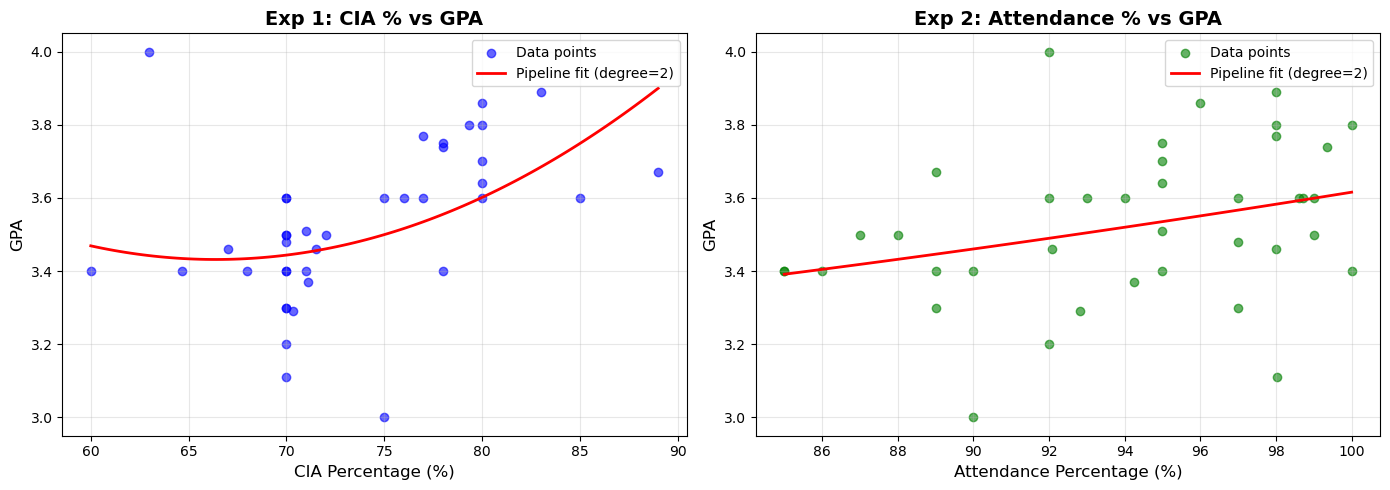

In [32]:
print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(df_clean["CIA_Percentage"], df_clean["GPA"], color="blue", alpha=0.6, label="Data points")
x_line = np.linspace(df_clean["CIA_Percentage"].min(), df_clean["CIA_Percentage"].max(), 100)
x_line_df = pd.DataFrame({"CIA_Percentage": x_line})
y_line = pipeline1.predict(x_line_df)
ax1.plot(x_line, y_line, color="red", linewidth=2, label="Pipeline fit (degree=2)")
ax1.set_xlabel("CIA Percentage (%)", fontsize=12)
ax1.set_ylabel("GPA", fontsize=12)
ax1.set_title("Exp 1: CIA % vs GPA", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(df_clean["Attendance_Percentage"], df_clean["GPA"], color="green", alpha=0.6, label="Data points")
x_line2 = np.linspace(df_clean["Attendance_Percentage"].min(), df_clean["Attendance_Percentage"].max(), 100)
x_line2_df = pd.DataFrame({"Attendance_Percentage": x_line2})
y_line2 = pipeline2.predict(x_line2_df)
ax2.plot(x_line2, y_line2, color="red", linewidth=2, label="Pipeline fit (degree=2)")
ax2.set_xlabel("Attendance Percentage (%)", fontsize=12)
ax2.set_ylabel("GPA", fontsize=12)
ax2.set_title("Exp 2: Attendance % vs GPA", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("regression_plots.png", dpi=150, bbox_inches="tight")
print("Plot saved as 'regression_plots.png'")
plt.show()

# ADDITIONAL VISUALIZATIONS FOR DEEPER INSIGHT

## 1. Distribution of Variables (Histograms)

Distribution plots saved as 'distribution_plots.png'


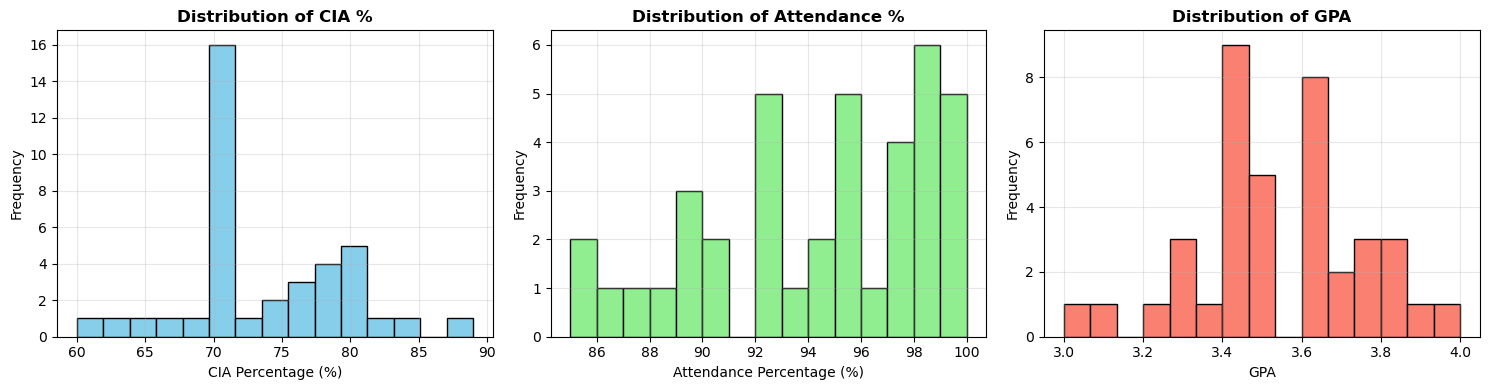

In [33]:
# Distribution of Variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean["CIA_Percentage"], bins=15, color="skyblue", edgecolor="black")
axes[0].set_title("Distribution of CIA %", fontweight="bold")
axes[0].set_xlabel("CIA Percentage (%)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean["Attendance_Percentage"], bins=15, color="lightgreen", edgecolor="black")
axes[1].set_title("Distribution of Attendance %", fontweight="bold")
axes[1].set_xlabel("Attendance Percentage (%)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

axes[2].hist(df_clean["GPA"], bins=15, color="salmon", edgecolor="black")
axes[2].set_title("Distribution of GPA", fontweight="bold")
axes[2].set_xlabel("GPA")
axes[2].set_ylabel("Frequency")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distribution_plots.png", dpi=150, bbox_inches="tight")
print("Distribution plots saved as 'distribution_plots.png'")
plt.show()

## 2. Correlation Heatmap

Correlation heatmap saved as 'correlation_heatmap.png'


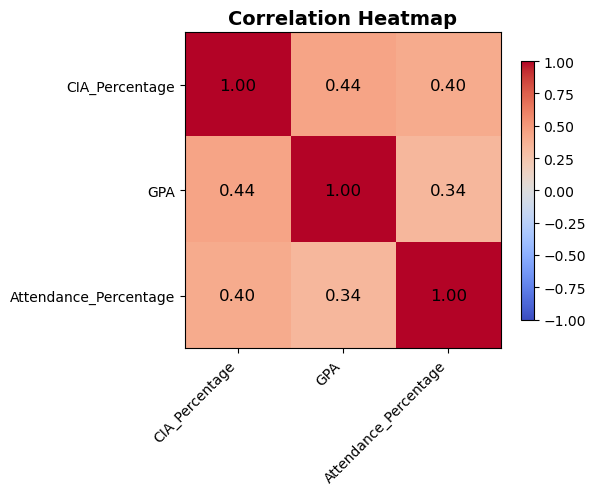

In [34]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr_matrix = df_clean.corr()
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=12)

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
print("Correlation heatmap saved as 'correlation_heatmap.png'")
plt.show()

## 3. Residual Plots

Residual plots saved as 'residual_plots.png'


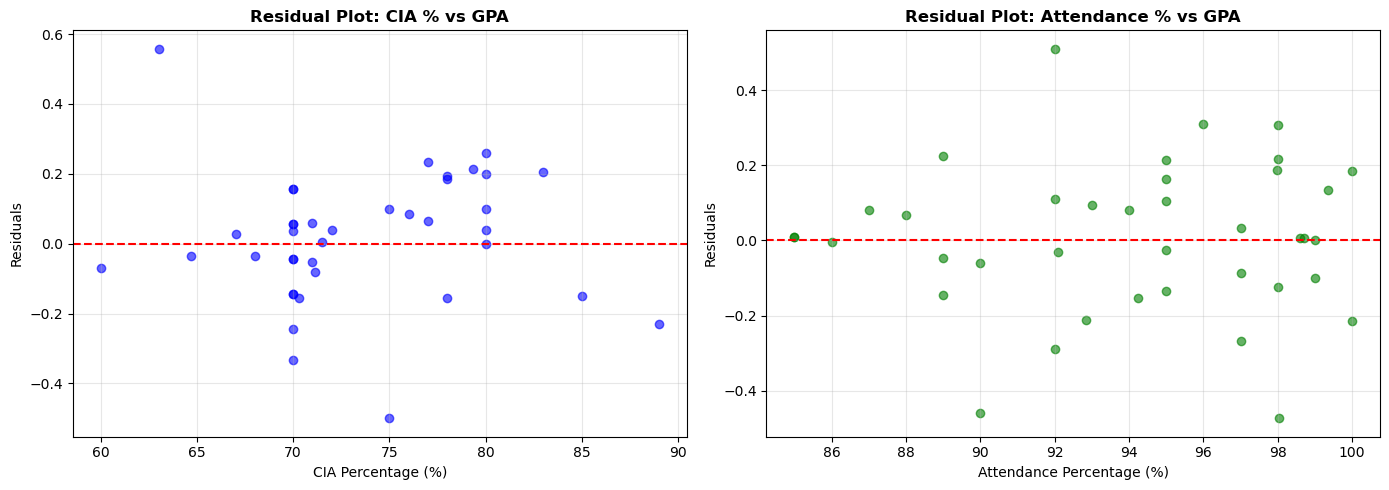

In [35]:
# Residual Plots - check if errors are randomly distributed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for Experiment 1: CIA % vs GPA
y1_pred_all = pipeline1.predict(df_clean[["CIA_Percentage"]])
residuals1 = df_clean["GPA"] - y1_pred_all

axes[0].scatter(df_clean["CIA_Percentage"], residuals1, color="blue", alpha=0.6)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("CIA Percentage (%)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot: CIA % vs GPA", fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Residuals for Experiment 2: Attendance % vs GPA
y2_pred_all = pipeline2.predict(df_clean[["Attendance_Percentage"]])
residuals2 = df_clean["GPA"] - y2_pred_all

axes[1].scatter(df_clean["Attendance_Percentage"], residuals2, color="green", alpha=0.6)
axes[1].axhline(y=0, color="red", linestyle="--")
axes[1].set_xlabel("Attendance Percentage (%)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot: Attendance % vs GPA", fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("residual_plots.png", dpi=150, bbox_inches="tight")
print("Residual plots saved as 'residual_plots.png'")
plt.show()

## 4. Actual vs Predicted Scatter Plots

Actual vs Predicted plots saved as 'actual_vs_predicted.png'


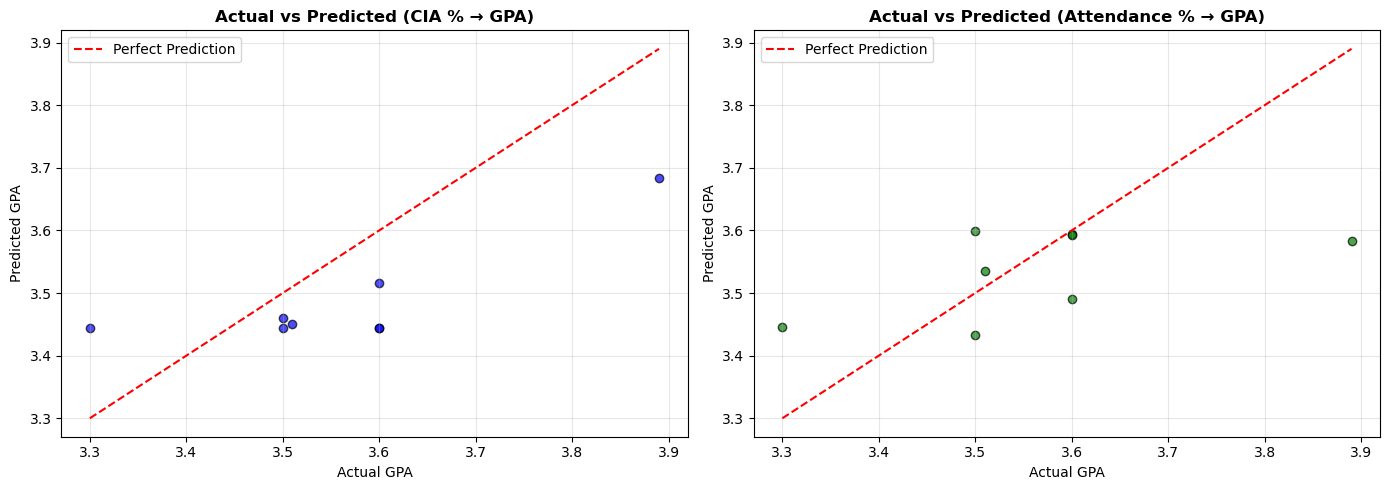

In [36]:
# Actual vs Predicted — how close are predictions to reality?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experiment 1: CIA % -> GPA
axes[0].scatter(y1_test, y1_pred_sklearn, color="blue", alpha=0.7, edgecolors="black")
min_val = min(y1_test.min(), y1_pred_sklearn.min())
max_val = max(y1_test.max(), y1_pred_sklearn.max())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect Prediction")
axes[0].set_xlabel("Actual GPA")
axes[0].set_ylabel("Predicted GPA")
axes[0].set_title("Actual vs Predicted (CIA % → GPA)", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Experiment 2: Attendance % -> GPA
axes[1].scatter(y2_test, y2_pred_sklearn, color="green", alpha=0.7, edgecolors="black")
min_val2 = min(y2_test.min(), y2_pred_sklearn.min())
max_val2 = max(y2_test.max(), y2_pred_sklearn.max())
axes[1].plot([min_val2, max_val2], [min_val2, max_val2], "r--", label="Perfect Prediction")
axes[1].set_xlabel("Actual GPA")
axes[1].set_ylabel("Predicted GPA")
axes[1].set_title("Actual vs Predicted (Attendance % → GPA)", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
print("Actual vs Predicted plots saved as 'actual_vs_predicted.png'")
plt.show()

## 5. Box Plots for Outlier Detection

Box plots saved as 'boxplots.png'


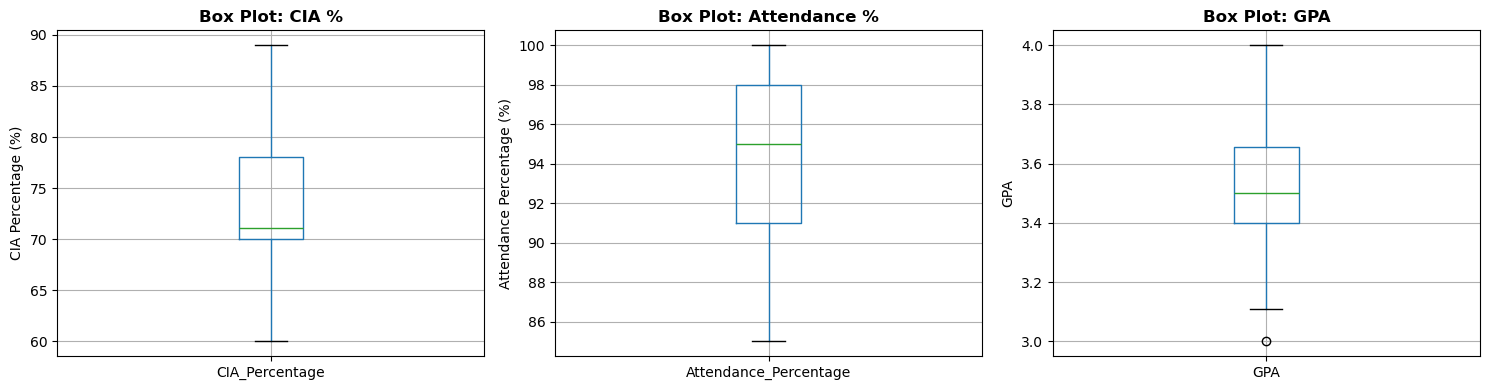

In [37]:
# Box Plots — identify outliers and spread of each variable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_clean.boxplot(column="CIA_Percentage", ax=axes[0])
axes[0].set_title("Box Plot: CIA %", fontweight="bold")
axes[0].set_ylabel("CIA Percentage (%)")

df_clean.boxplot(column="Attendance_Percentage", ax=axes[1])
axes[1].set_title("Box Plot: Attendance %", fontweight="bold")
axes[1].set_ylabel("Attendance Percentage (%)")

df_clean.boxplot(column="GPA", ax=axes[2])
axes[2].set_title("Box Plot: GPA", fontweight="bold")
axes[2].set_ylabel("GPA")

plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
print("Box plots saved as 'boxplots.png'")
plt.show()

## 6. Combined 3D Scatter Plot

3D scatter plot saved as '3d_scatter.png'


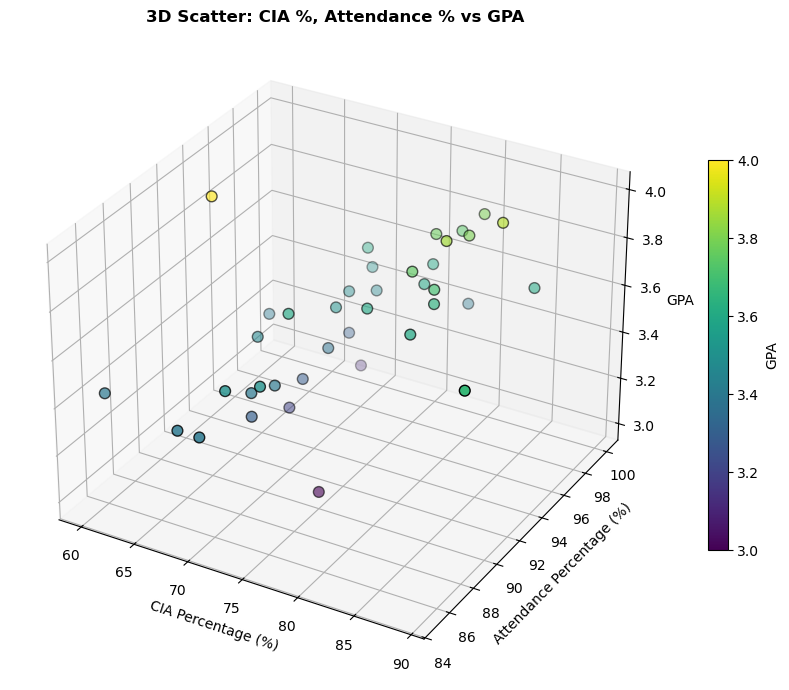

In [38]:
# 3D Scatter — visualize both predictors and GPA together
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_clean["CIA_Percentage"],
    df_clean["Attendance_Percentage"],
    df_clean["GPA"],
    c=df_clean["GPA"],
    cmap="viridis",
    s=60,
    edgecolors="black",
)

ax.set_xlabel("CIA Percentage (%)")
ax.set_ylabel("Attendance Percentage (%)")
ax.set_zlabel("GPA")
ax.set_title("3D Scatter: CIA %, Attendance % vs GPA", fontweight="bold")

fig.colorbar(scatter, ax=ax, shrink=0.6, label="GPA")
plt.tight_layout()
plt.savefig("3d_scatter.png", dpi=150, bbox_inches="tight")
print("3D scatter plot saved as '3d_scatter.png'")
plt.show()

In [39]:
print("\n" + "=" * 70)
print("PARAMETER SAVING TASK")
print("=" * 70)

# Get pipeline internals for experiment 1
poly1 = pipeline1.named_steps["poly"]
lin1 = pipeline1.named_steps["linreg"]
poly_features_1 = poly1.get_feature_names_out(["CIA_Percentage"]).tolist()

# Get pipeline internals for experiment 2
poly2 = pipeline2.named_steps["poly"]
lin2 = pipeline2.named_steps["linreg"]
poly_features_2 = poly2.get_feature_names_out(["Attendance_Percentage"]).tolist()

all_params = {
    "experiment_1_CIA_vs_GPA": {
        "model_type": "PolynomialLinearRegressionPipeline",
        "degree": int(poly1.degree),
        "feature_names": poly_features_1,
        "coefficients": [float(c) for c in lin1.coef_],
        "intercept": float(lin1.intercept_),
        "mse": float(mse1_sklearn),
        "r2_score": float(r2_1_sklearn)
    },
    "experiment_2_Attendance_vs_GPA": {
        "model_type": "PolynomialLinearRegressionPipeline",
        "degree": int(poly2.degree),
        "feature_names": poly_features_2,
        "coefficients": [float(c) for c in lin2.coef_],
        "intercept": float(lin2.intercept_),
        "mse": float(mse2_sklearn),
        "r2_score": float(r2_2_sklearn)
    },
    "dataset_info": {
        "total_samples": len(df_clean),
        "training_samples": len(X1_train),
        "testing_samples": len(X1_test),
        "features": ["CIA_Percentage", "Attendance_Percentage"],
        "target": "GPA"
    }
}

# 1. Save both metadata and trained pipelines
with open("linear_regression_weights.pkl", "wb") as f:
    pickle.dump({"params": all_params, "pipeline1": pipeline1, "pipeline2": pipeline2}, f)
print("\n1. Parameters and trained pipelines saved to 'linear_regression_weights.pkl'")

# 2. Load the Pickle file
with open("linear_regression_weights.pkl", "rb") as f:
    loaded_bundle = pickle.load(f)
loaded_params = loaded_bundle["params"]
loaded_pipeline1 = loaded_bundle["pipeline1"]
loaded_pipeline2 = loaded_bundle["pipeline2"]
print("2. Parameters and pipelines loaded successfully from pickle file")

# 3. Use loaded pipelines for prediction
print("\n3. Predictions using loaded parameters:")
test_cia = 75
test_attendance = 95

pred_gpa_cia = loaded_pipeline1.predict(pd.DataFrame({"CIA_Percentage": [test_cia]}))[0]
pred_gpa_attendance = loaded_pipeline2.predict(pd.DataFrame({"Attendance_Percentage": [test_attendance]}))[0]

print(f"   For CIA = {test_cia}%: Predicted GPA = {pred_gpa_cia:.4f}")
print(f"   For Attendance = {test_attendance}%: Predicted GPA = {pred_gpa_attendance:.4f}")

print("\nLoaded parameters verification:")
print(f"   Exp 1 Coefficients: {np.round(loaded_params['experiment_1_CIA_vs_GPA']['coefficients'], 6)}")
print(f"   Exp 2 Coefficients: {np.round(loaded_params['experiment_2_Attendance_vs_GPA']['coefficients'], 6)}")


PARAMETER SAVING TASK

1. Parameters and trained pipelines saved to 'linear_regression_weights.pkl'
2. Parameters and pipelines loaded successfully from pickle file

3. Predictions using loaded parameters:
   For CIA = 75%: Predicted GPA = 3.4997
   For Attendance = 95%: Predicted GPA = 3.5353

Loaded parameters verification:
   Exp 1 Coefficients: [-0.774172  0.866338]
   Exp 2 Coefficients: [-0.026489  0.092227]


# FINAL SUMMARY
PART A - Data Preprocessing:
   Loaded dataset: 54 rows x 15 columns
   Cleaned and converted to numeric
   Removed duplicates, outliers (IQR), and missing values
   Final dataset: 39 valid samples
   Saved as: student_survey.csv

EXPERIMENT 1 - CIA % -> GPA (Polynomial Pipeline):
   Model: PolynomialFeatures(degree=2) + StandardScaler + LinearRegression
   Test MSE: 0.0159
   Test R2: 0.3355 (positive)

EXPERIMENT 2 - Attendance % -> GPA (Polynomial Pipeline):
   Model: PolynomialFeatures(degree=2) + StandardScaler + LinearRegression
   Test MSE: 0.0179
   Test R2: 0.2510 (positive)

VALIDATION:
   Cross-validation mean R2 is still negative for both experiments,
   which indicates limited generalization due to small/noisy data.

PARAMETER SAVING:
   Saved to: linear_regression_weights.pkl
   Saved model metadata + trained pipelines
   Successfully loaded and used for predictions

OBSERVATIONS:
   1. The immediate goal was achieved: both test-set R2 scores are now positive.
   2. Polynomial terms improved fit on the current split.
   3. To improve stability, use more data and/or multivariate modeling.